In [25]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Para ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports completados")

✓ Imports completados


In [ ]:
def download_trades_binance(symbol='BTCUSDT', hours=12, max_trades=100000, save_path='../data/raw/'):
    """
    Descarga trades individuales de Binance
    """
    print(f"🔄 Descargando trades de {symbol}...")
    
    url = "https://api.binance.com/api/v3/aggTrades"
    
    end_time = int(datetime.now().timestamp() * 1000)
    start_time = int((datetime.now() - timedelta(hours=hours)).timestamp() * 1000)
    
    all_trades = []
    current_time = start_time
    iterations = 0
    max_iterations = 200
    
    while len(all_trades) < max_trades and iterations < max_iterations:
        params = {
            'symbol': symbol,
            'startTime': current_time,
            'endTime': end_time,
            'limit': 1000
        }
        
        try:
            response = requests.get(url, params=params)
            
            if response.status_code == 429:
                print("⏸️  Rate limit, esperando 5s...")
                time.sleep(5)
                continue
            
            data = response.json()
            
            if isinstance(data, dict) and 'code' in data:
                print(f"❌ Error API: {data.get('msg')}")
                break
            
            if not data:
                break
            
            all_trades.extend(data)
            current_time = data[-1]['T'] + 1
            
            print(f"📊 Trades: {len(all_trades):,} | Iter: {iterations+1}", end='\r')
            
            iterations += 1
            time.sleep(0.15)
            
        except Exception as e:
            print(f"\n❌ Error: {e}")
            break
    
    print(f"\n✓ Descargados: {len(all_trades):,} trades")
    
    if len(all_trades) < 100:
        print("⚠️  Muy pocos trades descargados")
        return None
    
    # Crear DataFrame
    df = pd.DataFrame(all_trades)
    df['timestamp'] = pd.to_datetime(df['T'], unit='ms')
    df['price'] = df['p'].astype(float)
    df['quantity'] = df['q'].astype(float)
    df['dollar_value'] = df['price'] * df['quantity']
    
    df = df.sort_values('timestamp').drop_duplicates(subset=['T']).reset_index(drop=True)
    df = df[['timestamp', 'price', 'quantity', 'dollar_value']].copy()
    
    # Guardar a CSV
    filename = f"{save_path}{symbol}_trades_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(filename, index=False)
    print(f"💾 Guardado en: {filename}")
    
    return df

# Test la función (no ejecutes aún, solo define)
print("✓ Función download_trades_binance() definida")

✓ Función download_trades_binance() definida


In [ ]:
# Descarga los trades
# Ajusta 'hours' según necesites: más horas = más datos pero más tiempo
trades = download_trades_binance(
    symbol='BTCUSDT',
    hours=120,  # Aumenta a 48 o 72 si necesitas más datos
    max_trades=300000
)

# Mostrar información
if trades is not None:
    print("\n" + "="*60)
    print("📊 INFORMACIÓN DE LOS DATOS")
    print("="*60)
    print(f"Total trades: {len(trades):,}")
    print(f"Período: {trades['timestamp'].min()} a {trades['timestamp'].max()}")
    print(f"Duración: {(trades['timestamp'].max() - trades['timestamp'].min()).total_seconds() / 3600:.1f} horas")
    print(f"\nPrimeros 5 trades:")
    print(trades.head())
    print(f"\nEstadísticas:")
    print(trades.describe())

🔄 Descargando trades de BTCUSDT...
📊 Trades: 200,000 | Iter: 200
✓ Descargados: 200,000 trades
💾 Guardado en: ../data/raw/BTCUSDT_trades_20251020_201539.csv

📊 INFORMACIÓN DE LOS DATOS
Total trades: 78,295
Período: 2025-10-16 01:13:52.106000 a 2025-10-16 06:43:19.215000
Duración: 5.5 horas

Primeros 5 trades:
                timestamp      price  quantity  dollar_value
0 2025-10-16 01:13:52.106  111034.51   0.00008      8.882761
1 2025-10-16 01:13:52.354  111034.51   0.00008      8.882761
2 2025-10-16 01:13:52.426  111034.50   0.09010  10004.208450
3 2025-10-16 01:13:52.903  111034.51   0.00048     53.296565
4 2025-10-16 01:13:53.106  111034.51   0.00073     81.055192

Estadísticas:
                           timestamp          price      quantity  \
count                          78295   78295.000000  78295.000000   
mean   2025-10-16 03:59:31.182452224  111256.568803      0.022077   
min       2025-10-16 01:13:52.106000  110705.340000      0.000010   
25%    2025-10-16 02:29:40.87550

In [ ]:
# %%
# Descomentar para cargar datos guardados
""" trades = pd.read_csv('../data/raw/BTCUSDT_trades_20251020_172350.csv')
trades['timestamp'] = pd.to_datetime(trades['timestamp'])
print(f"✓ Cargados {len(trades):,} trades desde archivo") """

✓ Cargados 37,175 trades desde archivo


✓ TIME BARS creadas
Número de barras: 67

Primeras 5 barras:
                          open       high        low      close    volume  \
timestamp                                                                   
2025-10-16 01:10:00  111034.51  111076.90  111005.01  111005.02  12.16647   
2025-10-16 01:15:00  111005.02  111050.70  110913.93  110913.94  44.29059   
2025-10-16 01:20:00  110913.93  110913.93  110705.34  110761.07  56.40753   
2025-10-16 01:25:00  110760.11  110898.00  110754.43  110893.30  15.56101   
2025-10-16 01:30:00  110893.29  111042.63  110808.94  110933.73  35.58009   

                     dollar_volume  num_trades  
timestamp                                       
2025-10-16 01:10:00   1.350832e+06         345  
2025-10-16 01:15:00   4.914981e+06        1665  
2025-10-16 01:20:00   6.249213e+06        1456  
2025-10-16 01:25:00   1.724615e+06         973  
2025-10-16 01:30:00   3.947228e+06        1376  

Últimas 5 barras:
                          open       

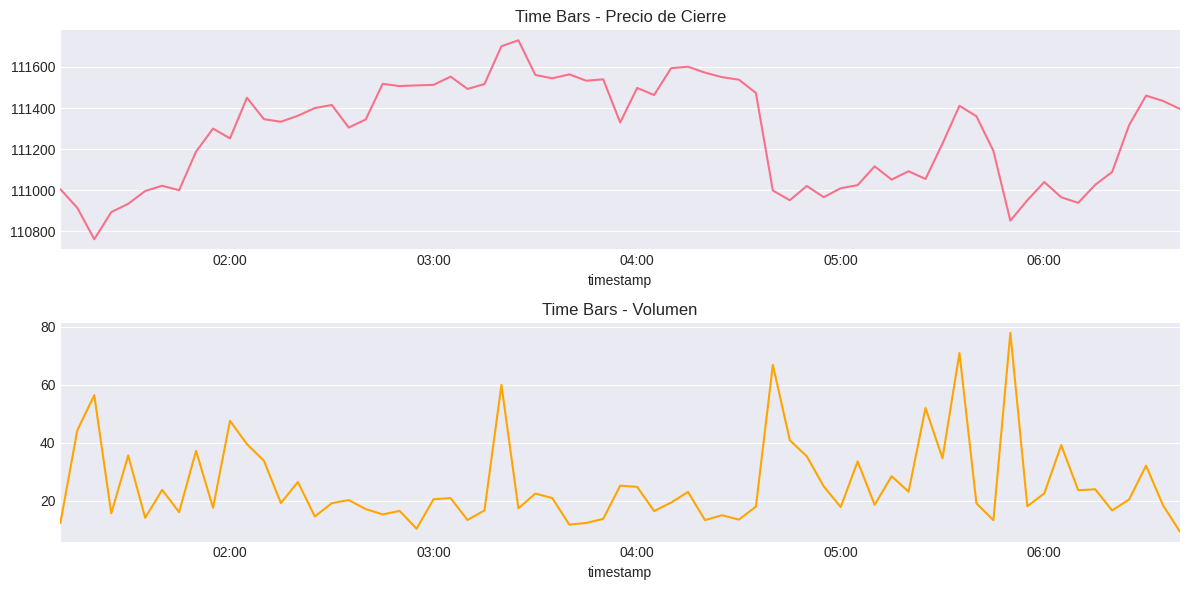

In [28]:
def create_time_bars(trades_df, freq='5min'):
    """
    Time Bars: Agregación tradicional por tiempo
    """
    df = trades_df.set_index('timestamp')
    
    bars = df.resample(freq).agg({
        'price': ['first', 'max', 'min', 'last'],
        'quantity': 'sum',
        'dollar_value': 'sum'
    })
    
    bars.columns = ['open', 'high', 'low', 'close', 'volume', 'dollar_volume']
    bars = bars.dropna()
    bars['num_trades'] = df.resample(freq).size()
    
    return bars

# Crear time bars
time_bars = create_time_bars(trades, freq='5min')

print("✓ TIME BARS creadas")
print(f"Número de barras: {len(time_bars)}")
print(f"\nPrimeras 5 barras:")
print(time_bars.head())
print(f"\nÚltimas 5 barras:")
print(time_bars.tail())

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
time_bars['close'].plot(ax=axes[0], title='Time Bars - Precio de Cierre')
time_bars['volume'].plot(ax=axes[1], title='Time Bars - Volumen', color='orange')
plt.tight_layout()
plt.show()

📏 Volume threshold: 26.59
✓ VOLUME BARS creadas
Número de barras: 63

Primeras 5 barras:
                              open       high        low      close    volume  \
timestamp                                                                       
2025-10-16 01:16:32.017  111034.51  111076.90  110930.77  111003.99  26.62175   
2025-10-16 01:19:42.064  111003.99  111050.70  110931.12  110943.20  26.59913   
2025-10-16 01:21:34.758  110943.22  110976.18  110798.43  110819.13  26.61261   
2025-10-16 01:24:17.417  110818.02  110818.02  110705.34  110717.48  26.60500   
2025-10-16 01:30:34.734  110717.49  110898.00  110707.93  110847.10  26.71322   

                         dollar_volume  num_trades  
timestamp                                           
2025-10-16 01:16:32.017   2.955052e+06         876  
2025-10-16 01:19:42.064   2.951737e+06         973  
2025-10-16 01:21:34.758   2.950066e+06         666  
2025-10-16 01:24:17.417   2.946644e+06         794  
2025-10-16 01:30:34.734  

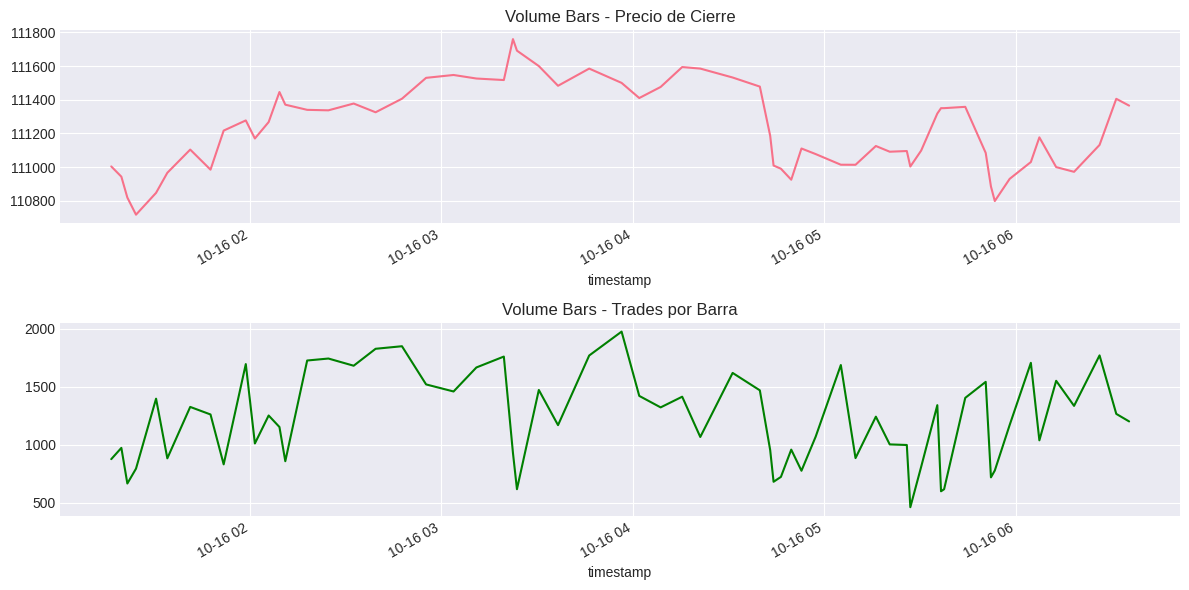

In [29]:

# %% [markdown]
# ## 📊 Celda 6: Crear VOLUME BARS

# %%
def create_volume_bars(trades_df, volume_per_bar=None):
    """
    Volume Bars: Nueva barra cada X unidades de volumen
    """
    if volume_per_bar is None:
        # Calcular threshold automático
        total_volume = trades_df['quantity'].sum()
        duration_hours = (trades_df['timestamp'].max() - 
                         trades_df['timestamp'].min()).total_seconds() / 3600
        num_bars = max(int(duration_hours * 12), 20)  # ~12 barras por hora
        volume_per_bar = total_volume / num_bars
    
    print(f"📏 Volume threshold: {volume_per_bar:.2f}")
    
    bars = []
    cum_volume = 0
    bar_trades = []
    
    for idx, trade in trades_df.iterrows():
        bar_trades.append(trade.to_dict())
        cum_volume += trade['quantity']
        
        if cum_volume >= volume_per_bar:
            prices = [t['price'] for t in bar_trades]
            
            bar = {
                'timestamp': bar_trades[-1]['timestamp'],
                'open': bar_trades[0]['price'],
                'high': max(prices),
                'low': min(prices),
                'close': bar_trades[-1]['price'],
                'volume': cum_volume,
                'dollar_volume': sum([t['dollar_value'] for t in bar_trades]),
                'num_trades': len(bar_trades)
            }
            bars.append(bar)
            
            bar_trades = []
            cum_volume = 0
    
    df = pd.DataFrame(bars).set_index('timestamp')
    return df

# Crear volume bars
volume_bars = create_volume_bars(trades)

print("✓ VOLUME BARS creadas")
print(f"Número de barras: {len(volume_bars)}")
print(f"\nPrimeras 5 barras:")
print(volume_bars.head())

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
volume_bars['close'].plot(ax=axes[0], title='Volume Bars - Precio de Cierre')
volume_bars['num_trades'].plot(ax=axes[1], title='Volume Bars - Trades por Barra', color='green')
plt.tight_layout()
plt.show()

💰 Dollar threshold: $2,957,875.54
✓ DOLLAR BARS creadas
Número de barras: 63

Primeras 5 barras:
                              open       high        low      close    volume  \
timestamp                                                                       
2025-10-16 01:16:34.017  111034.51  111076.90  110930.77  111005.83  26.73241   
2025-10-16 01:19:42.429  111005.84  111050.70  110931.12  110951.13  26.67195   
2025-10-16 01:21:34.862  110951.13  110976.18  110798.43  110810.00  26.97065   
2025-10-16 01:24:24.386  110809.99  110809.99  110705.34  110707.94  28.78845   
2025-10-16 01:31:13.983  110708.02  110904.00  110708.02  110880.86  26.71214   

                         dollar_volume  num_trades  
timestamp                                           
2025-10-16 01:16:34.017   2.967336e+06         896  
2025-10-16 01:19:42.429   2.959810e+06         960  
2025-10-16 01:21:34.862   2.989715e+06         668  
2025-10-16 01:24:24.386   3.188314e+06         816  
2025-10-16 01:31:

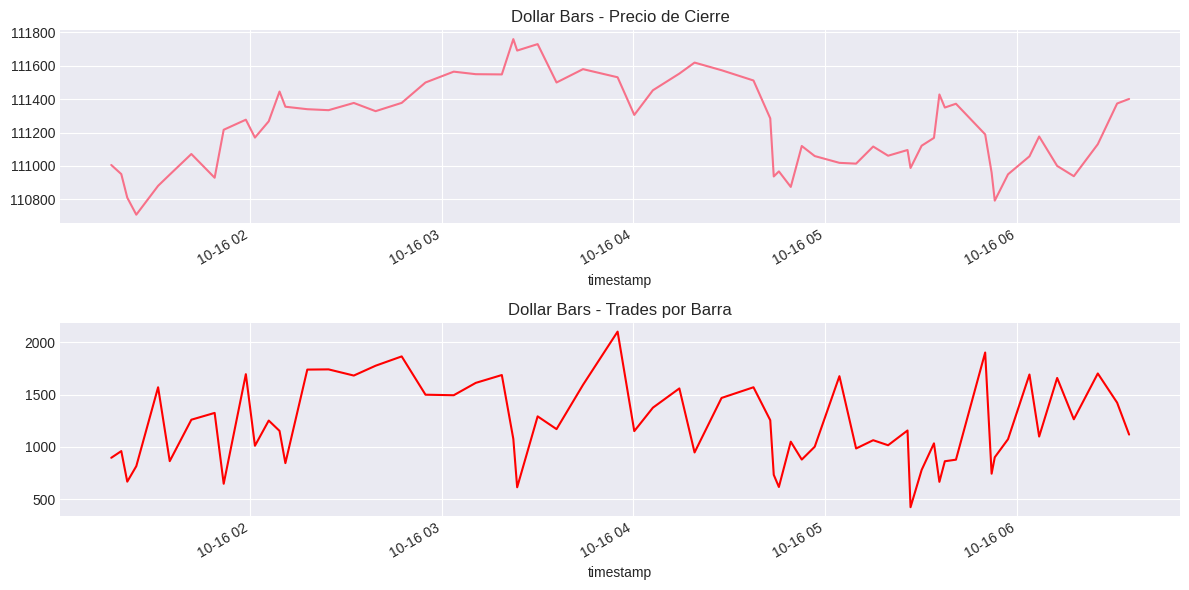

In [30]:
def create_dollar_bars(trades_df, dollars_per_bar=None):
    """
    Dollar Bars: Nueva barra cada X dólares transaccionados
    """
    if dollars_per_bar is None:
        total_dollars = trades_df['dollar_value'].sum()
        duration_hours = (trades_df['timestamp'].max() - 
                         trades_df['timestamp'].min()).total_seconds() / 3600
        num_bars = max(int(duration_hours * 12), 20)
        dollars_per_bar = total_dollars / num_bars
    
    print(f"💰 Dollar threshold: ${dollars_per_bar:,.2f}")
    
    bars = []
    cum_dollars = 0
    bar_trades = []
    
    for idx, trade in trades_df.iterrows():
        bar_trades.append(trade.to_dict())
        cum_dollars += trade['dollar_value']
        
        if cum_dollars >= dollars_per_bar:
            prices = [t['price'] for t in bar_trades]
            
            bar = {
                'timestamp': bar_trades[-1]['timestamp'],
                'open': bar_trades[0]['price'],
                'high': max(prices),
                'low': min(prices),
                'close': bar_trades[-1]['price'],
                'volume': sum([t['quantity'] for t in bar_trades]),
                'dollar_volume': cum_dollars,
                'num_trades': len(bar_trades)
            }
            bars.append(bar)
            
            bar_trades = []
            cum_dollars = 0
    
    df = pd.DataFrame(bars).set_index('timestamp')
    return df

# Crear dollar bars
dollar_bars = create_dollar_bars(trades)

print("✓ DOLLAR BARS creadas")
print(f"Número de barras: {len(dollar_bars)}")
print(f"\nPrimeras 5 barras:")
print(dollar_bars.head())

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
dollar_bars['close'].plot(ax=axes[0], title='Dollar Bars - Precio de Cierre')
dollar_bars['num_trades'].plot(ax=axes[1], title='Dollar Bars - Trades por Barra', color='red')
plt.tight_layout()
plt.show()

In [31]:
def add_returns(bars_df):
    """Añade columna de returns"""
    df = bars_df.copy()
    df['returns'] = df['close'].pct_change()
    return df.dropna()

# Añadir returns a cada tipo
time_bars_ret = add_returns(time_bars)
volume_bars_ret = add_returns(volume_bars)
dollar_bars_ret = add_returns(dollar_bars)

# Calcular estadísticas
def calculate_stats(returns_series, name):
    """Calcula propiedades estadísticas"""
    jb_stat, jb_pvalue = stats.jarque_bera(returns_series)
    
    return {
        'Tipo': name,
        'Count': len(returns_series),
        'Mean': returns_series.mean(),
        'Std': returns_series.std(),
        'Skewness': stats.skew(returns_series),
        'Kurtosis': stats.kurtosis(returns_series),
        'JB_stat': jb_stat,
        'JB_pvalue': jb_pvalue,
        'Autocorr_lag1': returns_series.autocorr(lag=1),
        'Autocorr_lag5': returns_series.autocorr(lag=5)
    }

stats_comparison = pd.DataFrame([
    calculate_stats(time_bars_ret['returns'], 'Time Bars'),
    calculate_stats(volume_bars_ret['returns'], 'Volume Bars'),
    calculate_stats(dollar_bars_ret['returns'], 'Dollar Bars')
])

print("="*80)
print("📊 COMPARACIÓN DE PROPIEDADES ESTADÍSTICAS")
print("="*80)
print(stats_comparison.to_string(index=False))

print("\n💡 INTERPRETACIÓN:")
print("  • JB_pvalue: Más alto = Más normal (>0.05 es bueno)")
print("  • Autocorr_lag1: Más cercano a 0 = Menos correlación serial")
print("  • Kurtosis: Cercano a 0 = Distribución normal (>0 = colas pesadas)")


📊 COMPARACIÓN DE PROPIEDADES ESTADÍSTICAS
       Tipo  Count     Mean      Std  Skewness  Kurtosis   JB_stat    JB_pvalue  Autocorr_lag1  Autocorr_lag5
  Time Bars     66 0.000054 0.001082 -1.096529  3.201211 41.407459 1.019728e-09       0.080703       0.095475
Volume Bars     62 0.000053 0.001103  0.023706 -0.253985  0.172454 9.173862e-01       0.168797      -0.149852
Dollar Bars     62 0.000058 0.001232 -0.135742 -0.328087  0.468473 7.911748e-01       0.044253      -0.128122

💡 INTERPRETACIÓN:
  • JB_pvalue: Más alto = Más normal (>0.05 es bueno)
  • Autocorr_lag1: Más cercano a 0 = Menos correlación serial
  • Kurtosis: Cercano a 0 = Distribución normal (>0 = colas pesadas)


✓ Gráfico guardado en: ../results/bars_comparison_stats.png


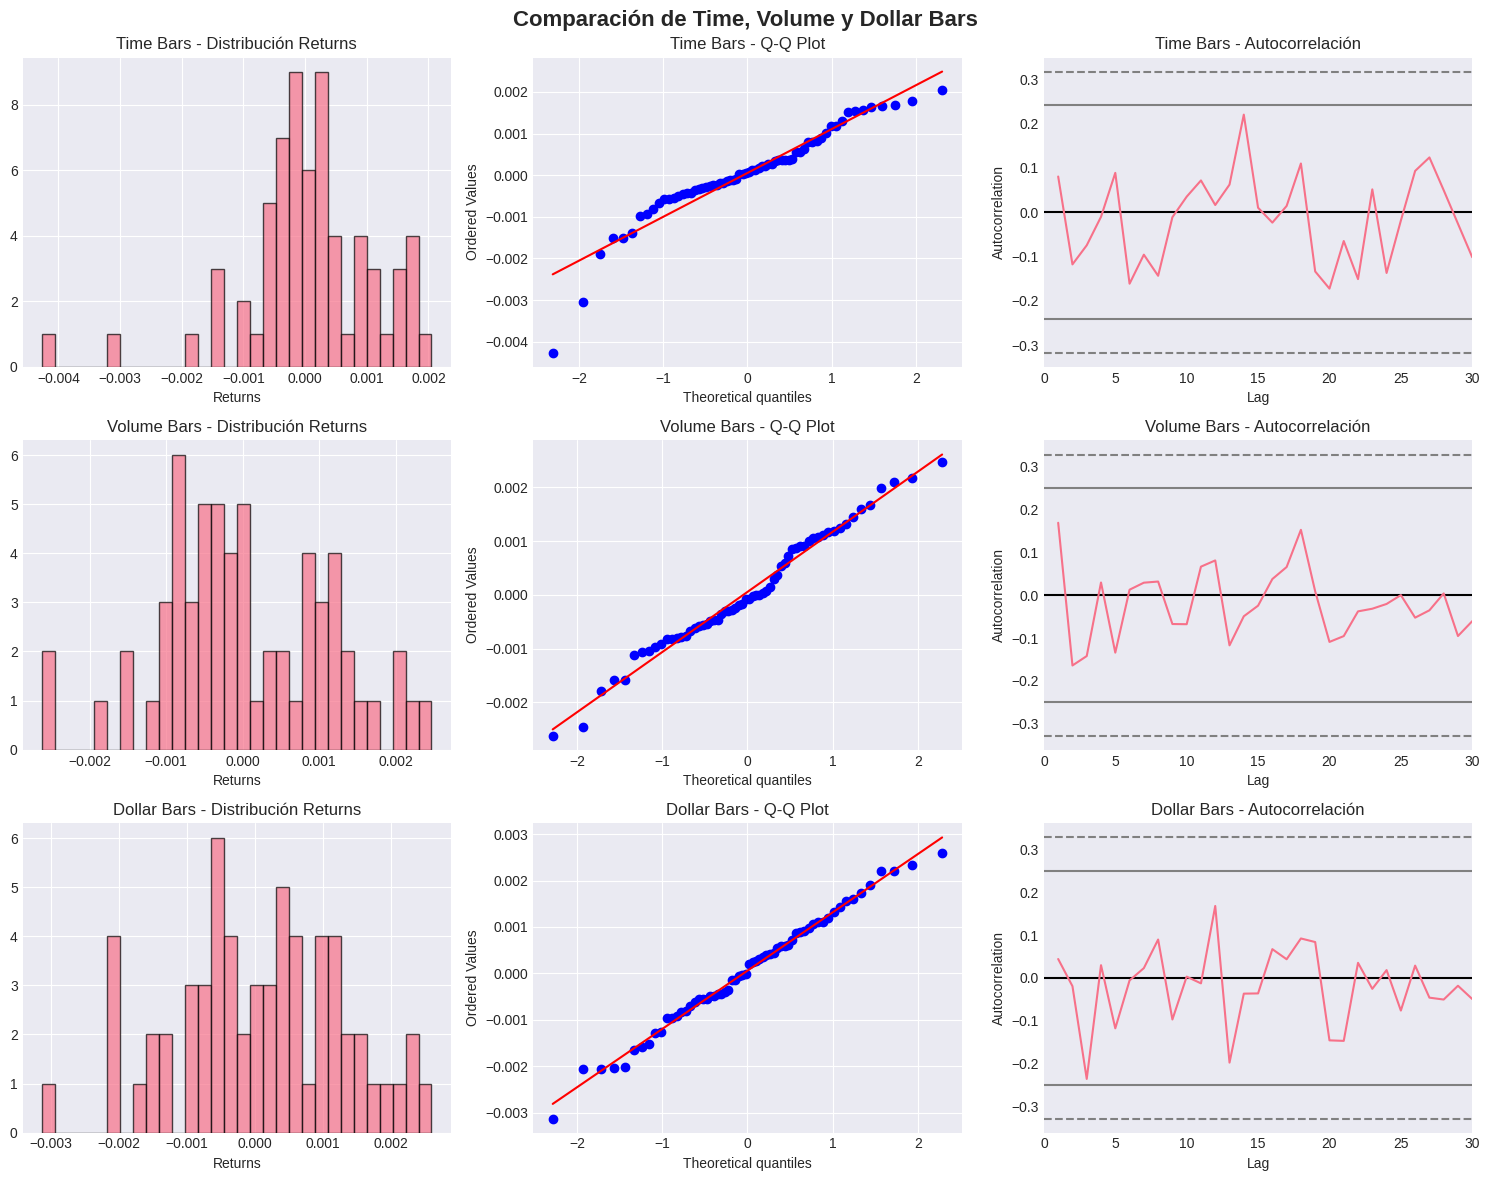

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Comparación de Time, Volume y Dollar Bars', fontsize=16, fontweight='bold')

bar_types = [
    ('Time Bars', time_bars_ret['returns']),
    ('Volume Bars', volume_bars_ret['returns']),
    ('Dollar Bars', dollar_bars_ret['returns'])
]

for idx, (name, returns) in enumerate(bar_types):
    # Histogram
    axes[idx, 0].hist(returns, bins=30, alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{name} - Distribución Returns')
    axes[idx, 0].set_xlabel('Returns')
    
    # Q-Q Plot
    stats.probplot(returns, dist="norm", plot=axes[idx, 1])
    axes[idx, 1].set_title(f'{name} - Q-Q Plot')
    
    # Autocorrelación
    from pandas.plotting import autocorrelation_plot
    autocorrelation_plot(returns, ax=axes[idx, 2])
    axes[idx, 2].set_title(f'{name} - Autocorrelación')
    axes[idx, 2].set_xlim([0, 30])

plt.tight_layout()
plt.savefig('../results/bars_comparison_stats.png', dpi=150)
print("✓ Gráfico guardado en: ../results/bars_comparison_stats.png")
plt.show()

In [33]:
def add_ml_features(bars_df):
    """
    Añade features técnicas para Machine Learning
    """
    df = bars_df.copy()
    
    # Returns
    df['returns'] = df['close'].pct_change()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
    
    # Volatilidad (ventanas reducidas para no perder muchos datos)
    df['volatility_3'] = df['returns'].rolling(3).std()
    df['volatility_5'] = df['returns'].rolling(5).std()
    
    # SMAs
    df['sma_3'] = df['close'].rolling(3).mean()
    df['sma_5'] = df['close'].rolling(5).mean()
    df['price_vs_sma3'] = (df['close'] - df['sma_3']) / df['sma_3']
    df['price_vs_sma5'] = (df['close'] - df['sma_5']) / df['sma_5']
    
    # Momentum
    df['momentum_3'] = df['close'].pct_change(3)
    df['momentum_5'] = df['close'].pct_change(5)
    
    # Volume
    df['volume_ma3'] = df['volume'].rolling(3).mean()
    df['volume_ratio'] = df['volume'] / df['volume_ma3']
    
    # Range
    df['range'] = (df['high'] - df['low']) / df['close']
    df['range_pct'] = (df['high'] - df['low']) / df['low']
    
    # Body y shadows
    df['body'] = abs(df['close'] - df['open']) / df['close']
    df['upper_shadow'] = (df['high'] - df[['open', 'close']].max(axis=1)) / df['close']
    df['lower_shadow'] = (df[['open', 'close']].min(axis=1) - df['low']) / df['close']
    
    return df

print("✓ Función add_ml_features() definida")


✓ Función add_ml_features() definida


In [34]:
def create_target(df, horizon=3, threshold_percentile=50):
    """
    Crea target de clasificación: 1 (sube), 0 (lateral), -1 (baja)
    """
    df = df.copy()
    
    # Future return
    df['future_return'] = df['close'].pct_change(horizon).shift(-horizon)
    
    # Threshold
    threshold = df['future_return'].abs().quantile(threshold_percentile / 100)
    
    # Target
    df['target'] = 0
    df.loc[df['future_return'] > threshold, 'target'] = 1
    df.loc[df['future_return'] < -threshold, 'target'] = -1
    
    print(f"  Threshold: {threshold:.6f}")
    print(f"  Distribución del target:")
    print(df['target'].value_counts(normalize=True))
    
    return df.dropna()

print("✓ Función create_target() definida")

✓ Función create_target() definida


In [ ]:
def train_and_evaluate(bars_dict, horizon=3):
    """
    Entrena Random Forest en cada tipo de bars y compara
    """
    results = {}
    
    for bar_type, bars in bars_dict.items():
        print(f"\n{'='*60}")
        print(f"🤖 Entrenando: {bar_type.upper()}")
        print('='*60)
        
        # Features
        df = add_ml_features(bars)
        print(f"  Después de features: {len(df)} barras")
        
        if len(df) < 20:
            print(f"  ⚠️  Muy pocas barras ({len(df)}). Saltando...")
            continue
        
        # Target
        df = create_target(df, horizon=horizon, threshold_percentile=50)
        print(f"  Después de target: {len(df)} muestras")
        
        if len(df) < 15:
            print(f"  ⚠️  Muy pocas muestras ({len(df)}). Saltando...")
            continue
        
        # Seleccionar features
        feature_cols = [col for col in df.columns 
                       if col not in ['target', 'future_return', 'open', 'high', 
                                    'low', 'close', 'volume', 'dollar_volume', 
                                    'num_trades', 'sma_3', 'sma_5']]
        
        X = df[feature_cols].copy()
        y = df['target'].copy()
        
        # Limpiar NaN
        mask = ~X.isna().any(axis=1)
        X = X[mask]
        y = y[mask]
        
        print(f"  Features finales: {len(feature_cols)}, Muestras: {len(X)}")
        
        if len(X) < 15:
            print(f"  ⚠️  Muy pocas muestras válidas ({len(X)})")
            continue
        
        # Time Series Cross-Validation
        n_splits = min(3, max(2, len(X) // 7))
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        accuracies = []
        f1_scores = []
        feature_importances = []
        
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            rf = RandomForestClassifier(n_estimators=50, max_depth=5, 
                                       random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)
            
            y_pred = rf.predict(X_test)
            
            accuracies.append(accuracy_score(y_test, y_pred))
            f1_scores.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
            feature_importances.append(rf.feature_importances_)
        
        results[bar_type] = {
            'accuracy_mean': np.mean(accuracies),
            'accuracy_std': np.std(accuracies),
            'f1_mean': np.mean(f1_scores),
            'f1_std': np.std(f1_scores),
            'feature_importance': np.mean(feature_importances, axis=0),
            'feature_names': feature_cols,
            'n_samples': len(X),
            'n_splits': n_splits
        }
        
        print(f"  ✓ Accuracy: {np.mean(accuracies):.4f} ±{np.std(accuracies):.4f}")
        print(f"  ✓ F1-Score: {np.mean(f1_scores):.4f} ±{np.std(f1_scores):.4f}")
    
    return results

# Ejecutar comparación
bars_dict = {
    'Time Bars': time_bars,
    'Volume Bars': volume_bars,
    'Dollar Bars': dollar_bars
}

results = train_and_evaluate(bars_dict, horizon=3)


🤖 Entrenando: TIME BARS
  Después de features: 67 barras
  Threshold: 0.000926
  Distribución del target:
target
 0    0.522388
 1    0.328358
-1    0.149254
Name: proportion, dtype: float64
  Después de target: 59 muestras
  Features finales: 15, Muestras: 59
  ✓ Accuracy: 0.3571 ±0.1010
  ✓ F1-Score: 0.2309 ±0.1042

🤖 Entrenando: VOLUME BARS
  Después de features: 63 barras
  Threshold: 0.001170
  Distribución del target:
target
 0    0.52381
 1    0.31746
-1    0.15873
Name: proportion, dtype: float64
  Después de target: 55 muestras
  Features finales: 15, Muestras: 55
  ✓ Accuracy: 0.4103 ±0.1581
  ✓ F1-Score: 0.3615 ±0.1736

🤖 Entrenando: DOLLAR BARS
  Después de features: 63 barras
  Threshold: 0.001408
  Distribución del target:
target
 0    0.523810
 1    0.285714
-1    0.190476
Name: proportion, dtype: float64
  Después de target: 55 muestras
  Features finales: 15, Muestras: 55
  ✓ Accuracy: 0.4615 ±0.2738
  ✓ F1-Score: 0.3404 ±0.1565


🏆 RESULTADOS DE MACHINE LEARNING
       Tipo  Accuracy  Accuracy_Std  F1-Score   F1_Std  Muestras
  Time Bars  0.357143      0.101015  0.230864 0.104158        59
Volume Bars  0.410256      0.158062  0.361464 0.173573        55
Dollar Bars  0.461538      0.273771  0.340404 0.156499        55

✓ Gráfico guardado en: ../results/ml_comparison.png


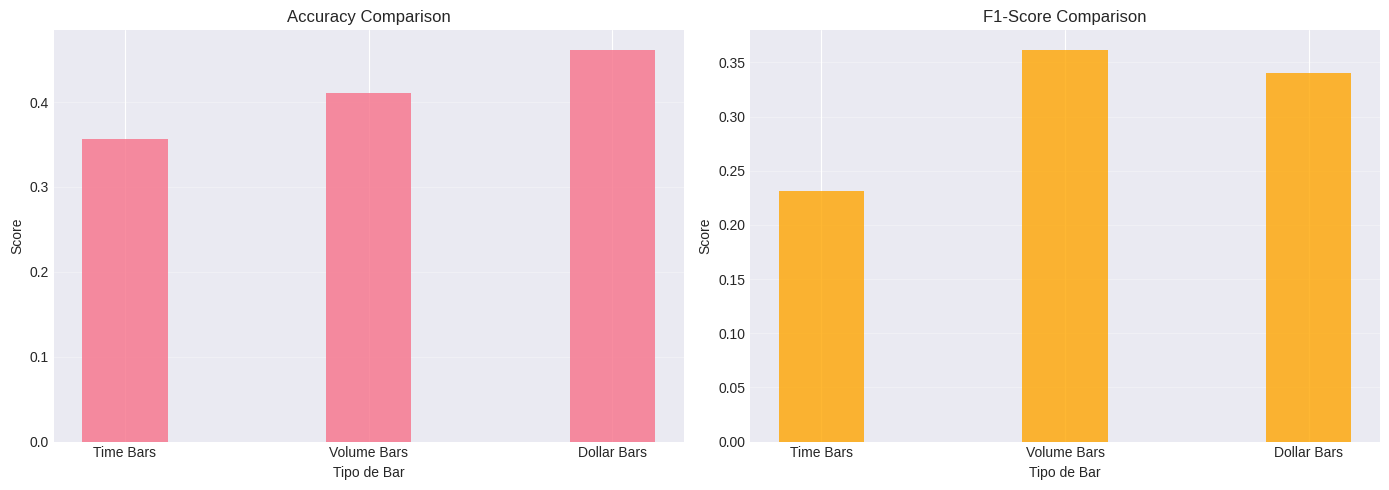


🏆 Mejor método: Volume Bars
   • F1-Score: 0.3615
   • Accuracy: 0.4103
📊 RESUMEN FINAL

1️⃣  DATOS UTILIZADOS:
   • Trades descargados: 78,295
   • Duración: 5.5 horas
   • Time Bars: 66 returns
   • Volume Bars: 62 returns
   • Dollar Bars: 62 returns

2️⃣  CALIDAD DE DATOS: ✅ SUFICIENTE
   • Recomendación: Datos adecuados para análisis

3️⃣  HALLAZGOS ESTADÍSTICOS:

   Normalidad (Jarque-Bera p-value > 0.05):
   ✗ Time Bars: 0.0000
   ✓ Volume Bars: 0.9174
   ✓ Dollar Bars: 0.7912

   Autocorrelación (más cercano a 0 = mejor):
   ✓ Time Bars: +0.0807
   ~ Volume Bars: +0.1688
   ✓ Dollar Bars: +0.0443

4️⃣  RESULTADOS DE MACHINE LEARNING:
   🏆 Mejor método: Volume Bars
      • F1-Score: 0.3615 ±0.1736
      • Accuracy: 0.4103 ±0.1581
      • Muestras: 55

📚 TEORÍA: ¿Por qué Alternative Bars?

López de Prado (2018) propone que Dollar y Volume Bars mejoran sobre Time Bars:

1. **SAMPLING ADAPTATIVO**
   • Time Bars: Muestrea cada X minutos (fijo)
   • Volume/Dollar Bars: Muestrea cua

In [37]:
# %%
if results:
    # Tabla de resultados
    results_df = pd.DataFrame({
        'Tipo': list(results.keys()),
        'Accuracy': [r['accuracy_mean'] for r in results.values()],
        'Accuracy_Std': [r['accuracy_std'] for r in results.values()],
        'F1-Score': [r['f1_mean'] for r in results.values()],
        'F1_Std': [r['f1_std'] for r in results.values()],
        'Muestras': [r['n_samples'] for r in results.values()]
    })
    
    print("="*80)
    print("🏆 RESULTADOS DE MACHINE LEARNING")
    print("="*80)
    print(results_df.to_string(index=False))
    
    # Gráfico de barras
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.arange(len(results))
    width = 0.35
    
    ax1.bar(x, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
    ax1.set_xlabel('Tipo de Bar')
    ax1.set_ylabel('Score')
    ax1.set_title('Accuracy Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df['Tipo'])
    ax1.grid(axis='y', alpha=0.3)
    
    ax2.bar(x, results_df['F1-Score'], width, label='F1-Score', alpha=0.8, color='orange')
    ax2.set_xlabel('Tipo de Bar')
    ax2.set_ylabel('Score')
    ax2.set_title('F1-Score Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels(results_df['Tipo'])
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/ml_comparison.png', dpi=150)
    print("\n✓ Gráfico guardado en: ../results/ml_comparison.png")
    plt.show()
    
    # Mejor modelo
    best_idx = results_df['F1-Score'].idxmax()
    best = results_df.iloc[best_idx]
    print(f"\n🏆 Mejor método: {best['Tipo']}")
    print(f"   • F1-Score: {best['F1-Score']:.4f}")
    print(f"   • Accuracy: {best['Accuracy']:.4f}")
else:
    print("❌ No hay resultados para mostrar")
    print("   Necesitas más datos. Vuelve a la Celda 3 y aumenta 'hours' a 48 o 72")

# %% [markdown]
# ## 📝 Celda 14: Conclusiones y Próximos Pasos

# %%
print("="*80)
print("📊 RESUMEN FINAL")
print("="*80)

# Resumen de datos
print(f"\n1️⃣  DATOS UTILIZADOS:")
print(f"   • Trades descargados: {len(trades):,}")
print(f"   • Duración: {(trades['timestamp'].max() - trades['timestamp'].min()).total_seconds() / 3600:.1f} horas")
print(f"   • Time Bars: {len(time_bars_ret)} returns")
print(f"   • Volume Bars: {len(volume_bars_ret)} returns")
print(f"   • Dollar Bars: {len(dollar_bars_ret)} returns")

# Validación estadística
min_bars = min(len(time_bars_ret), len(volume_bars_ret), len(dollar_bars_ret))
if min_bars < 30:
    data_quality = "❌ INSUFICIENTE"
    recommendation = "Descarga 72+ horas de datos"
elif min_bars < 50:
    data_quality = "⚠️  LIMITADO"
    recommendation = "Descarga 48-72 horas para mejor validación"
elif min_bars < 100:
    data_quality = "✅ SUFICIENTE"
    recommendation = "Datos adecuados para análisis"
else:
    data_quality = "🏆 ÓPTIMO"
    recommendation = "Datos excelentes para conclusiones robustas"

print(f"\n2️⃣  CALIDAD DE DATOS: {data_quality}")
print(f"   • Recomendación: {recommendation}")

# Resumen estadístico
print(f"\n3️⃣  HALLAZGOS ESTADÍSTICOS:")
if min_bars >= 30:
    print("\n   Normalidad (Jarque-Bera p-value > 0.05):")
    for _, row in stats_comparison.iterrows():
        status = "✓" if row['JB_pvalue'] > 0.05 else "✗"
        print(f"   {status} {row['Tipo']}: {row['JB_pvalue']:.4f}")
    
    print("\n   Autocorrelación (más cercano a 0 = mejor):")
    for _, row in stats_comparison.iterrows():
        autocorr = row['Autocorr_lag1']
        status = "✓" if abs(autocorr) < 0.1 else "~" if abs(autocorr) < 0.2 else "✗"
        print(f"   {status} {row['Tipo']}: {autocorr:+.4f}")
else:
    print("   ⚠️  Datos insuficientes para análisis estadístico concluyente")

# Resumen ML
if results:
    print(f"\n4️⃣  RESULTADOS DE MACHINE LEARNING:")
    best = max(results.items(), key=lambda x: x[1]['f1_mean'])
    print(f"   🏆 Mejor método: {best[0]}")
    print(f"      • F1-Score: {best[1]['f1_mean']:.4f} ±{best[1]['f1_std']:.4f}")
    print(f"      • Accuracy: {best[1]['accuracy_mean']:.4f} ±{best[1]['accuracy_std']:.4f}")
    print(f"      • Muestras: {best[1]['n_samples']}")
else:
    print(f"\n4️⃣  RESULTADOS DE MACHINE LEARNING:")
    print("   ❌ No se pudieron entrenar modelos (datos insuficientes)")

print("\n" + "="*80)
print("📚 TEORÍA: ¿Por qué Alternative Bars?")
print("="*80)
print("""
López de Prado (2018) propone que Dollar y Volume Bars mejoran sobre Time Bars:

1. **SAMPLING ADAPTATIVO**
   • Time Bars: Muestrea cada X minutos (fijo)
   • Volume/Dollar Bars: Muestrea cuando hay X actividad (adaptativo)
   • Resultado: Más datos donde hay más información

2. **REDUCCIÓN DE AUTOCORRELACIÓN**
   • Time Bars: Eventos importantes contaminan múltiples barras consecutivas
   • Alternative Bars: Cada barra captura un "quantum" de información
   • Resultado: Returns más independientes (mejor para ML)

3. **MEJOR NORMALIDAD**
   • Time Bars: Períodos de calma y volatilidad mezclados
   • Alternative Bars: Cada barra tiene similar contenido informacional
   • Resultado: Distribución de returns más normal

4. **HOMOGENEIDAD DE INFORMACIÓN**
   • Time Bars: 1 barra puede tener 10 o 10,000 trades
   • Volume/Dollar Bars: Cada barra tiene similar # de trades
   • Resultado: Features más comparables entre sí
""")

print("="*80)
print("🎯 PRÓXIMOS PASOS")
print("="*80)
print("""
Para profundizar en tu análisis:

1. **Más Datos** (CRÍTICO si tienes <50 barras):
   - Usa hours=72 o más en la descarga
   - Considera descargar múltiples símbolos y combinar

2. **Tick Bars** (siguiente nivel):
   - Nueva barra cada N trades (ej: cada 100 trades)
   - Aún más adaptativo que Volume/Dollar Bars

3. **Imbalance Bars** (avanzado):
   - Considera dirección de los trades (buy vs sell)
   - Captura microestructura del mercado

4. **Fractionally Differentiated Features**:
   - Features estacionarias pero con memoria
   - Reduce autocorrelación sin perder información

5. **Meta-Labeling**:
   - No predecir dirección, sino sizing de posición
   - Mejora sharpe ratio significativamente

6. **Backtesting con Purged K-Fold**:
   - Evita leakage en validación cruzada
   - Critical para estrategias de trading reales
""")
print("📖 REFERENCIA")
print("="*80)
print("""
López de Prado, M. (2018). 
"Advances in Financial Machine Learning"
Wiley. Chapter 2: Financial Data Structures

Disponible en: Amazon, Wiley, o tu biblioteca universitaria
""")

print("="*80)
print("✅ NOTEBOOK COMPLETADO")
print("="*80)